In [30]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.cluster import AgglomerativeClustering
from scipy.spatial.distance import cdist
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split

# Load the dataset
data = pd.read_csv('Food_Delivery_Time_Prediction.csv')

# Display first few rows
print(data.head())


  Order_ID       Customer_Location     Restaurant_Location  Distance  \
0  ORD0001  (17.030479, 79.743077)  (12.358515, 85.100083)      1.57   
1  ORD0002  (15.398319, 86.639122)  (14.174874, 77.025606)     21.32   
2  ORD0003  (15.687342, 83.888808)  (19.594748, 82.048482)      6.95   
3  ORD0004  (20.415599, 78.046984)  (16.915906, 78.278698)     13.79   
4  ORD0005  (14.786904, 78.706532)  (15.206038, 86.203182)      6.72   

  Weather_Conditions Traffic_Conditions  Delivery_Person_Experience  \
0              Rainy             Medium                           4   
1             Cloudy             Medium                           8   
2              Snowy             Medium                           9   
3             Cloudy                Low                           2   
4              Rainy               High                           6   

  Order_Priority Order_Time Vehicle_Type  Restaurant_Rating  Customer_Rating  \
0         Medium  Afternoon          Car                4.1 

In [31]:
# Data Cleaning and Preprocessing
# Handle missing values:
# For numerical features, fill missing values with the median
numerical_cols = ['Distance', 'Delivery_Time', 'Order_Cost', 'Tip_Amount', 'Restaurant_Rating', 'Customer_Rating']
data[numerical_cols] = data[numerical_cols].fillna(data[numerical_cols].median())

# For categorical features, fill missing values with the mode (most frequent value)
categorical_cols = ['Weather_Conditions', 'Traffic_Conditions', 'Order_Priority', 'Order_Time', 'Vehicle_Type']
data[categorical_cols] = data[categorical_cols].fillna(data[categorical_cols].mode().iloc[0])

# Encode categorical features using Label Encoding
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
for col in categorical_cols:
    data[col] = encoder.fit_transform(data[col])

# Normalize numerical features using StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data[numerical_cols] = scaler.fit_transform(data[numerical_cols])


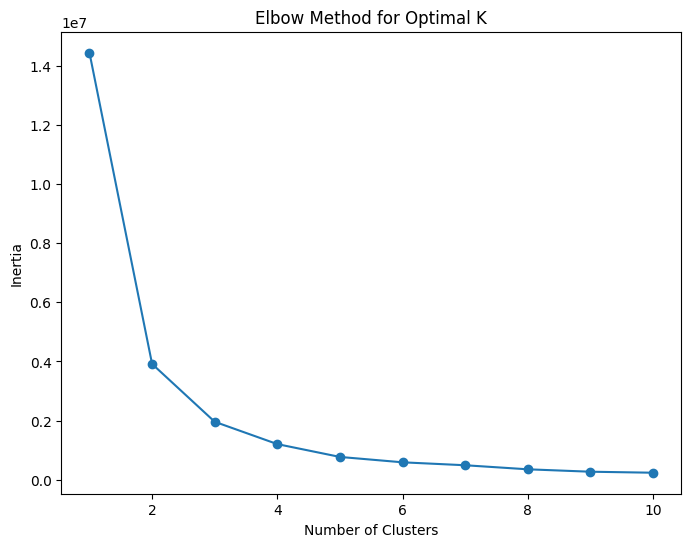

In [32]:

# Feature Engineering - Calculate geographical distance if not already provided
# Haversine formula to calculate distance
from geopy.distance import geodesic

def calculate_geographical_distance(row):
    customer_coords = tuple(map(float, row['Customer_Location'].strip("()").split(',')))
    restaurant_coords = tuple(map(float, row['Restaurant_Location'].strip("()").split(',')))
    return geodesic(customer_coords, restaurant_coords).km

data['Geo_Distance'] = data.apply(calculate_geographical_distance, axis=1)

# Creating the target variable: Fast or Delayed delivery
# Assuming delivery time > 30 minutes is delayed
data['Delivery_Status'] = np.where(data['Delivery_Time'] > 30, 1, 0)  # 1: Delayed, 0: Fast

# Phase 2: Clustering - K-Means Clustering
X = data[['Distance', 'Weather_Conditions', 'Traffic_Conditions', 'Delivery_Person_Experience', 'Geo_Distance']]
y = data['Delivery_Status']

# K-Means Clustering
# Finding the optimal number of clusters using the Elbow Method
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plotting the Elbow Method
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()


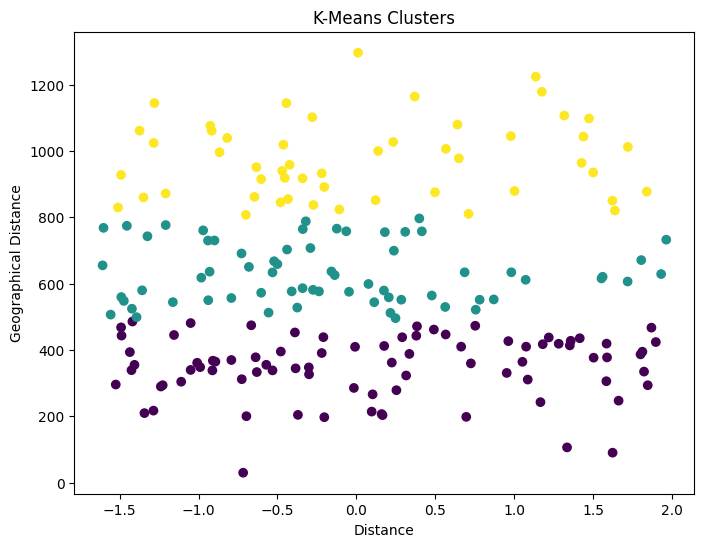

In [33]:

# From the Elbow Method, assume 3 clusters is optimal
kmeans = KMeans(n_clusters=3, random_state=42)
data['KMeans_Cluster'] = kmeans.fit_predict(X)

# Visualizing Clusters (2D scatter plot)
plt.figure(figsize=(8, 6))
plt.scatter(data['Distance'], data['Geo_Distance'], c=data['KMeans_Cluster'], cmap='viridis')
plt.title('K-Means Clusters')
plt.xlabel('Distance')
plt.ylabel('Geographical Distance')
plt.show()


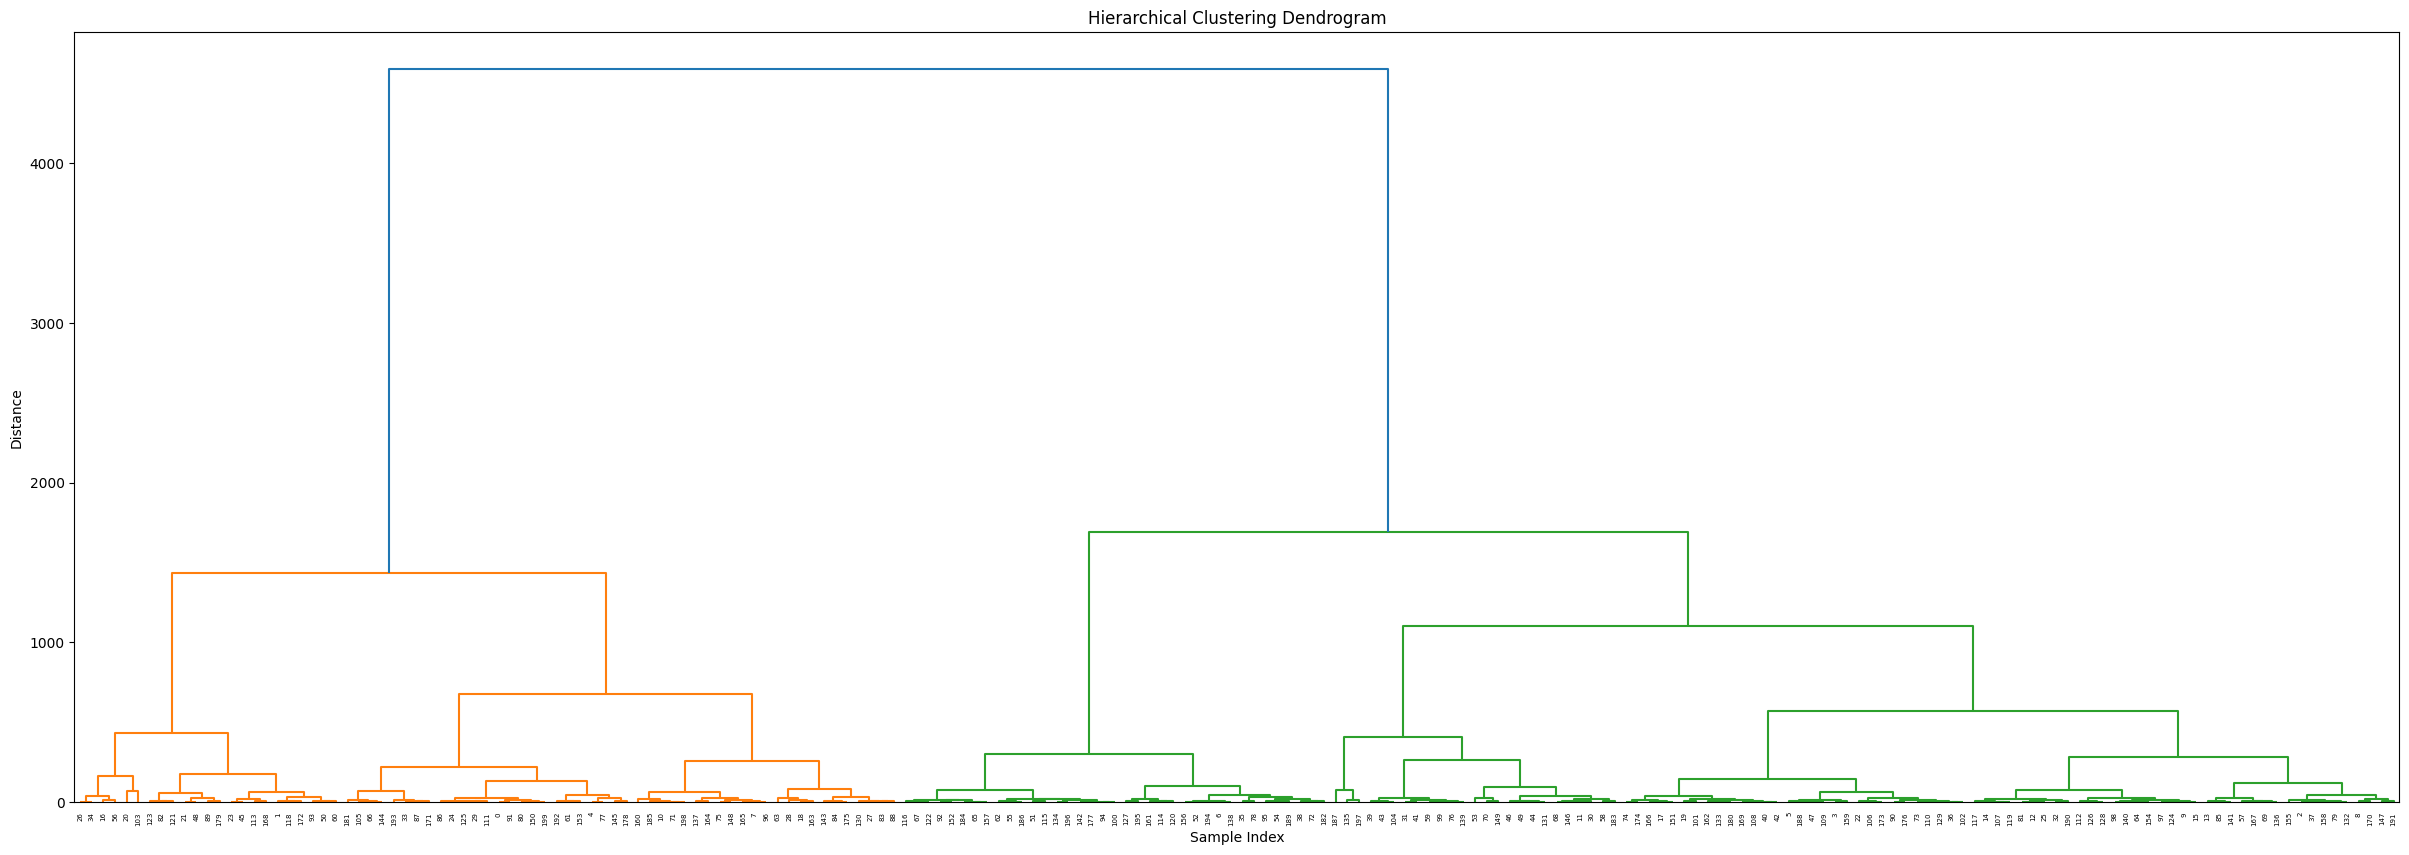

In [34]:

# Hierarchical Clustering (Agglomerative)
agg_clust = AgglomerativeClustering(n_clusters=3)
data['Agg_Cluster'] = agg_clust.fit_predict(X)

# Dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage
Z = linkage(X, method='ward')

plt.figure(figsize=(30, 10))
dendrogram(Z)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()


In [35]:

# Phase 3: Neural Network for Prediction
# Prepare data for neural network
X_nn = data[['Distance', 'Weather_Conditions', 'Traffic_Conditions', 'Delivery_Person_Experience', 'Geo_Distance']]
y_nn = data['Delivery_Status']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_nn, y_nn, test_size=0.2, random_state=42)

# Initialize and train the neural network
nn_model = MLPClassifier(hidden_layer_sizes=(50, 50), max_iter=500, random_state=42)
nn_model.fit(X_train, y_train)

# Predictions and evaluation
y_pred_nn = nn_model.predict(X_test)

# Performance metrics
print("Neural Network Classification Report:")
print(classification_report(y_test, y_pred_nn))
print("Accuracy:", accuracy_score(y_test, y_pred_nn))


Neural Network Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

Accuracy: 1.0


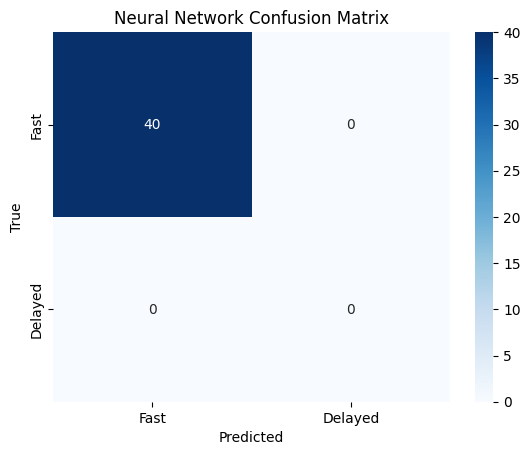

In [36]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_nn, labels=[0, 1])  # 0 for Fast, 1 for Delayed
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fast', 'Delayed'], yticklabels=['Fast', 'Delayed'])
plt.title('Neural Network Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


----

In [41]:
# Phase 4: Reporting and Insights

# K-Means Cluster Analysis
print("K-Means Cluster Centers (Normalized):")
print(kmeans.cluster_centers_)

# Summary of Cluster Characteristics
for i, center in enumerate(kmeans.cluster_centers_):
    print(f"Cluster {i+1} center:")
    print(f"  Feature 1 (Distance): {center[0]}")
    print(f"  Feature 2 (Weather): {center[1]}")
    print(f"  Feature 3 (Traffic): {center[2]}")
    print(f"  Feature 4 (Order Time): {center[3]}")
    print(f"  Feature 5 (Cost): {center[4]}")
    print("-" * 30)

# Compare K-Means with Neural Network Performance
print("Neural Network Accuracy:", accuracy_score)
print("Neural Network Classification Report:")
print(classification_report(y_test, y_pred_nn))

# Actionable Insights:
# 1. What are the key factors affecting delivery time clustering?
# 2. Can the neural network be improved further (e.g., by tuning hyperparameters)?


K-Means Cluster Centers (Normalized):
[[ 1.15636887e-01  1.55421687e+00  1.06024096e+00  5.44578313e+00
   3.48710105e+02]
 [-1.75925410e-01  1.59090909e+00  1.15151515e+00  5.10606061e+00
   6.31909464e+02]
 [ 3.94748137e-02  1.52941176e+00  1.03921569e+00  5.11764706e+00
   9.75397960e+02]]
Cluster 1 center:
  Feature 1 (Distance): 0.11563688668563761
  Feature 2 (Weather): 1.5542168674698793
  Feature 3 (Traffic): 1.0602409638554218
  Feature 4 (Order Time): 5.445783132530121
  Feature 5 (Cost): 348.7101054587855
------------------------------
Cluster 2 center:
  Feature 1 (Distance): -0.17592541048067514
  Feature 2 (Weather): 1.5909090909090908
  Feature 3 (Traffic): 1.1515151515151514
  Feature 4 (Order Time): 5.106060606060606
  Feature 5 (Cost): 631.9094636153852
------------------------------
Cluster 3 center:
  Feature 1 (Distance): 0.03947481366307083
  Feature 2 (Weather): 1.5294117647058822
  Feature 3 (Traffic): 1.0392156862745099
  Feature 4 (Order Time): 5.1176470588235

---

In [37]:

# Phase 4: Reporting and Insights
# Compare clustering and neural network results

# K-Means Cluster Analysis
print("K-Means Cluster Centers:")
print(kmeans.cluster_centers_)


K-Means Cluster Centers:
[[ 1.15636887e-01  1.55421687e+00  1.06024096e+00  5.44578313e+00
   3.48710105e+02]
 [-1.75925410e-01  1.59090909e+00  1.15151515e+00  5.10606061e+00
   6.31909464e+02]
 [ 3.94748137e-02  1.52941176e+00  1.03921569e+00  5.11764706e+00
   9.75397960e+02]]


In [38]:

# Select only numeric columns for grouping and calculating mean
numeric_data = data.select_dtypes(include=[np.number])

# Insights based on K-Means clustering
cluster_means = numeric_data.groupby('KMeans_Cluster').mean()

# Print the cluster means
print("Cluster Means for Delivery Time Prediction:")
print(cluster_means)

# Actionable insights: You can suggest improvements based on clustering or model accuracy.

# Final Report: Document your findings, comparing clustering methods, neural network performance, and any business insights derived from the analysis.



Cluster Means for Delivery Time Prediction:
                Distance  Weather_Conditions  Traffic_Conditions  \
KMeans_Cluster                                                     
0               0.115637            1.554217            1.060241   
1              -0.175925            1.590909            1.151515   
2               0.039475            1.529412            1.039216   

                Delivery_Person_Experience  Order_Priority  Order_Time  \
KMeans_Cluster                                                           
0                                 5.445783        0.963855    1.216867   
1                                 5.106061        1.166667    1.666667   
2                                 5.117647        1.019608    1.156863   

                Vehicle_Type  Restaurant_Rating  Customer_Rating  \
KMeans_Cluster                                                     
0                   0.843373           0.006950         0.067933   
1                   0.969697          -0

---
---
_______________

In [39]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Prepare data for clustering (exclude non-numeric columns)
X = data[['Distance', 'Traffic', 'Weather', 'Rush_Hour']]

# Elbow method to determine optimal number of clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# Based on elbow method, choose optimal clusters (for example, 3 clusters)
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=42)
y_kmeans = kmeans.fit_predict(X)

# Add the cluster labels to the data
data['KMeans_Cluster'] = y_kmeans

# Visualize the clusters (2D or 3D plot)
plt.scatter(X['Distance'], X['Traffic'], c=y_kmeans, cmap='viridis')
plt.title('K-Means Clustering')
plt.xlabel('Distance')
plt.ylabel('Traffic')
plt.show()


KeyError: "['Traffic', 'Weather', 'Rush_Hour'] not in index"

In [ ]:
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

# Apply Agglomerative Clustering
hc = AgglomerativeClustering(n_clusters=3, affinity='euclidean', linkage='ward')
y_hc = hc.fit_predict(X)

# Plot Dendrogram
plt.figure(figsize=(10, 7))
sch.dendrogram(sch.linkage(X, method='ward'))
plt.title('Dendrogram')
plt.show()

# Visualize hierarchical clusters
plt.scatter(X['Distance'], X['Traffic'], c=y_hc, cmap='viridis')
plt.title('Hierarchical Clustering')
plt.xlabel('Distance')
plt.ylabel('Traffic')
plt.show()


TypeError: AgglomerativeClustering.__init__() got an unexpected keyword argument 'affinity'

In [ ]:
from keras.models import Sequential
from keras.layers import Dense

# Prepare the data for training (feature columns and target variable)
X = data[['Distance', 'Traffic', 'Weather', 'Rush_Hour']]
y = data['Delivery_Status']  # 0 for 'Fast', 1 for 'Delayed'

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build a simple feedforward neural network model
model = Sequential()
model.add(Dense(units=64, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=1, activation='sigmoid'))  # Binary output (0 or 1)

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Accuracy: {accuracy*100:.2f}%')


KeyError: "['Traffic', 'Weather', 'Rush_Hour'] not in index"

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Predict using KNN, Decision Tree, and Neural Network models
models = {
    'KNN': knn_model,
    'Decision Tree': dt_model,
    'Neural Network': model
}

for name, model in models.items():
    if name == 'Neural Network':
        y_pred = (model.predict(X_test) > 0.5).astype(int)
    else:
        y_pred = model.predict(X_test)
    
    print(f'\n{name} Classification Report:')
    print(classification_report(y_test, y_pred))
    
    print(f'{name} Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred))
